In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [21]:
# parameters
N = 1e4
#lambd = 0.5
lambd = 0.2
c = 1 / (lambd * (1-lambd)) * np.exp(-1)

In [24]:
# get them samples
accepted_samples = []
total_samples_count = 0
start_time = time.perf_counter()
while len(accepted_samples) < N:
    U1 = np.random.uniform(0, 1)
    U2 = np.random.uniform(0, 1)
    X = -(1/lambd) * np.log(U1)
    fcg = (1-lambd)* np.exp(1) * X * np.exp(-X * (1-lambd))
    total_samples_count += 1
    if U2 < fcg:
        accepted_samples.append(X)
stop_time = time.perf_counter()

total_time = stop_time - start_time
mean_time = total_time / N
empirical_rate = N / total_samples_count

In [25]:
print(f"Total Time Taken: {total_time} s")
print(f"Mean Time Per Sample: {mean_time} s")
print(f"Empirical Rate of Acceptance: {empirical_rate}")
print(f"Analytical Rate: {1/c}")

Total Time Taken: 0.5316897000011522 s
Mean Time Per Sample: 5.316897000011522e-05 s
Empirical Rate of Acceptance: 0.43673843734987117
Analytical Rate: 0.4349250925534473


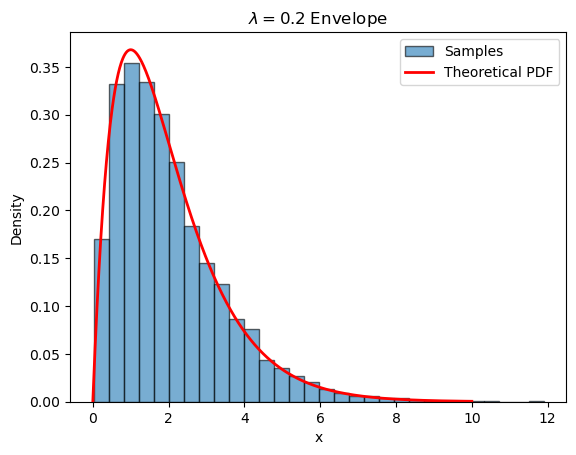

In [28]:
# plotting
x = np.linspace(0,10,1000)
f_true = x * np.exp(-x) # theoretical density for overlay

plt.hist(accepted_samples, bins=30, density=True, alpha=0.6, edgecolor='black', label='Samples')
plt.plot(x, f_true, 'r-', lw=2, label='Theoretical PDF')
#plt.title(r'$\lambda = 0.5$ Envelope')
plt.title(r'$\lambda = 0.2$ Envelope')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
